# SOFA scores for the PhysioNet/CinC Challenge 2012 cohort

This notebook applies the methodology in **`docs/task1_sofa/基于PhysioNet Challenge 2012数据集的SOFA计算方法.docx`**
to every one of the 12,000 ICU stays in `data/icu_records/`, then compares the result with the
`SOFA` column of `data/outcomes.csv`.

**Question under test:** is `outcomes.SOFA` the *worst* daily SOFA over the 48‑hour record,
or is it something else (e.g. the first‑24‑hour score)?

### What the methodology says (doc §1, §4, §9)

* Split the first 48 h into two **independent** 24 h windows: **Day 1 = `[0, 24)` h**,
  **Day 2 = `[24, 48)` h**.
* Inside each window every organ system independently takes its **worst** value; the six
  values need not be from the same timestamp.
* Map each system to 0–4 (doc §3 table) and sum → that window's SOFA.
* Report three fields (doc §9):
  * `SOFA_D1`  – Day‑1 total (used to reproduce / compare against `outcomes.SOFA`)
  * `SOFA_D2`  – Day‑2 total
  * `SOFA_48h_max = max(SOFA_D1, SOFA_D2)` – the highest **daily** SOFA in the first 48 h
* Doc §5 also asks for a **strict** companion: if any of the six components has no valid
  in‑window measurement, the window total is missing (`NaN`) instead of being summed as 0.

The six organ-system totals are **never** rebuilt by taking each system's max across the two
days (doc §4 "不要把 Day 1 和 Day 2 中六个系统各自的最高分重新拼成一个总分").


In [1]:
import csv, glob, time
from pathlib import Path

import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 60)

CWD = Path.cwd().resolve()
PROJ = next((p for p in (CWD, *CWD.parents) if (p / "data" / "icu_records").is_dir()), CWD)
DATA_DIR = PROJ / "data" / "icu_records"
OUTCOMES_CSV = PROJ / "data" / "outcomes.csv"

DAY1 = (0, 1440)          # minutes since admission, [0, 24) h
DAY2 = (1440, 2880)       # [24, 48) h
PAIR_WINDOW_MIN    = 120  # doc §5: PaO2 pairs with the nearest FiO2 / MechVent within +-2 h
URINE_MIN_SPAN_MIN = 1200 # doc §5/table 4: use the urine threshold only when the window's
                          #                 urine records span >= 20 h ("represent a full 24 h")

DESC_PARAMS = {"RecordID", "Age", "Gender", "Height", "ICUType", "Weight"}

files = sorted(glob.glob(str(DATA_DIR / "*.csv")))
print(len(files), "record files;", OUTCOMES_CSV.name, "present:", OUTCOMES_CSV.exists())


C:\Conda\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


12000 record files; outcomes.csv present: True


## 1&nbsp;&nbsp;Parsing and data cleaning

Doc §7 requires physiologically impossible values to be removed **before** scoring – they are
waveform dropouts / entry errors, not the `-1` missing sentinel:

| drop | doc count |
| --- | --- |
| empty `Parameter` rows (e.g. `02:08,,3.1`) | 2,403 rows / 1,594 records |
| `Value == -1` (missing sentinel) | — |
| `MAP == 0`, `NIMAP <= 0` | 86 rows |
| `PaO2 == 0` | 3 rows |
| `SaO2 == 0` | 2 rows |
| `Weight <= 20` kg | 353 rows |
| `Height < 100` or `> 250` cm | 17 / 11 rows |

`Time` is `HH:MM` elapsed since admission and runs past `24:00` (up to `47:59`); it is parsed
to integer minutes.


In [2]:
def keep_value(param, v):
    """doc §7 physiologic-plausibility filter (applied on top of the -1 sentinel)."""
    if v == -1:
        return False
    if param in ("MAP", "NIMAP", "PaO2", "SaO2") and v <= 0:
        return False
    if param == "Weight" and v <= 20:
        return False
    if param == "Height" and (v < 100 or v > 250):
        return False
    return True


def parse_record(path):
    """-> (series: {param: sorted [(t_min, value)]}, descriptors: {param: value})."""
    series, desc = {}, {}
    with open(path, newline="") as fh:
        r = csv.reader(fh)
        next(r, None)
        for row in r:
            if len(row) != 3:
                continue
            t_s, p, v_s = row
            if p == "":                     # doc §7: drop label-less rows
                continue
            try:
                hh, mm = t_s.split(":")
                t = int(hh) * 60 + int(mm)
                v = float(v_s)
            except ValueError:
                continue
            if not keep_value(p, v):
                continue
            if p in DESC_PARAMS and t == 0 and p not in desc:
                desc[p] = v
            series.setdefault(p, []).append((t, v))
    for p in series:
        series[p].sort()
    return series, desc


## 2&nbsp;&nbsp;Data-integrity audit (n = 12,000)

Reproduces the counts in doc §7 (Table 2 / notes) as a check that parsing and cleaning are
faithful before any score is computed.


In [3]:
audit = {k: 0 for k in ("empty_param_rows", "MAP_eq_0", "PaO2_eq_0", "SaO2_eq_0",
                         "Weight_neg1", "Weight_le20", "Weight_gt300",
                         "Height_lt100", "Height_gt250", "MechVent_rows")}
empty_param_records = set()
mechvent_values = set()
param_valid = {}                            # param -> valid-row count after cleaning
present = {"d1": {}, "d2": {}, "all": {}}   # param -> #records with >=1 valid value in window

def _bump(d, k): d[k] = d.get(k, 0) + 1

for f in files:
    seen = {"d1": set(), "d2": set(), "all": set()}
    with open(f, newline="") as fh:
        r = csv.reader(fh); next(r, None)
        for row in r:
            if len(row) != 3:
                continue
            t_s, p, v_s = row
            try:
                hh, mm = t_s.split(":"); t = int(hh) * 60 + int(mm); v = float(v_s)
            except ValueError:
                continue
            if p == "":
                audit["empty_param_rows"] += 1; empty_param_records.add(f); continue
            if p == "MAP"  and v == 0: audit["MAP_eq_0"]  += 1
            if p == "PaO2" and v == 0: audit["PaO2_eq_0"] += 1
            if p == "SaO2" and v == 0: audit["SaO2_eq_0"] += 1
            if p == "Weight":
                if v == -1:   audit["Weight_neg1"]  += 1
                elif v <= 20: audit["Weight_le20"]  += 1
                elif v > 300: audit["Weight_gt300"] += 1
            if p == "Height":
                if v != -1 and v < 100: audit["Height_lt100"] += 1
                if v > 250:             audit["Height_gt250"] += 1
            if p == "MechVent":
                audit["MechVent_rows"] += 1; mechvent_values.add(v)
            if keep_value(p, v):
                _bump(param_valid, p)
                for w, (lo, hi) in (("all", (0, 10**9)), ("d1", DAY1), ("d2", DAY2)):
                    if lo <= t < hi:
                        seen[w].add(p)
                        if p in ("MAP", "NIMAP"):
                            seen[w].add("MAP|NIMAP")
    for w in ("d1", "d2", "all"):
        for p in seen[w]:
            _bump(present[w], p)

n = len(files)
doc_ref = {"empty_param_rows": 2403, "empty_param_records": 1594, "MAP_eq_0": 86,
           "PaO2_eq_0": 3, "SaO2_eq_0": 2, "Weight_neg1": 1001, "Weight_le20": 353,
           "Weight_gt300": 1, "Height_lt100": 17, "Height_gt250": 11, "MechVent_rows": 91644}
got_all = dict(audit, empty_param_records=len(empty_param_records))
print("doc sec.7 spot checks (computed | doc):")
for k, doc in doc_ref.items():
    got = got_all[k]
    print(f"  {k:20} {got:>8}   | {doc:>8}   {'OK' if got == doc else 'DIFF'}")
print("  MechVent distinct values:", mechvent_values, "-> existence flag only (doc sec.7)")

param_valid["MAP|NIMAP"] = param_valid.get("MAP", 0) + param_valid.get("NIMAP", 0)
miss = pd.DataFrame({
    "valid_rows":   pd.Series(param_valid),
    "miss_48h_%":   100 * (1 - pd.Series(present["all"]) / n),
    "miss_Day1_%":  100 * (1 - pd.Series(present["d1"]) / n),
    "miss_Day2_%":  100 * (1 - pd.Series(present["d2"]) / n),
}).round(2)
ORDER = ["GCS", "Creatinine", "Urine", "MAP|NIMAP", "MAP", "NIMAP", "Platelets", "Weight",
         "PaO2", "FiO2", "MechVent", "SaO2", "Bilirubin"]
print("\nrecord-level missingness after cleaning. GCS/Creatinine/Urine/Platelets/FiO2/MechVent/")
print("Bilirubin valid_rows match doc table 4 exactly; PaO2/SaO2/Weight are 3/2/353 lower here")
print("because doc table 4 counts them BEFORE the sec.7 implausible-value cull. 'MAP|NIMAP' is")
print("the merged blood-pressure availability the doc's table-4 'MAP' row refers to.")
miss.loc[[p for p in ORDER if p in miss.index]]


doc sec.7 spot checks (computed | doc):
  empty_param_rows         2403   |     2403   OK
  empty_param_records      1594   |     1594   OK
  MAP_eq_0                   86   |       86   OK
  PaO2_eq_0                   3   |        3   OK
  SaO2_eq_0                   2   |        2   OK
  Weight_neg1              1001   |     1001   OK
  Weight_le20               353   |      353   OK
  Weight_gt300                1   |        1   OK
  Height_lt100               17   |       17   OK
  Height_gt250               11   |       11   OK
  MechVent_rows           91644   |    91644   OK
  MechVent distinct values: {1.0} -> existence flag only (doc sec.7)

record-level missingness after cleaning. GCS/Creatinine/Urine/Platelets/FiO2/MechVent/
Bilirubin valid_rows match doc table 4 exactly; PaO2/SaO2/Weight are 3/2/353 lower here
because doc table 4 counts them BEFORE the sec.7 implausible-value cull. 'MAP|NIMAP' is
the merged blood-pressure availability the doc's table-4 'MAP' row refers to.

,valid_rows,miss_48h_%,miss_Day1_%,miss_Day2_%
GCS,185991,1.54,1.76,1.90
Creatinine,41928,1.52,2.38,3.65
Urine,411163,2.58,2.92,4.37
MAP|NIMAP,731188,1.53,1.67,1.83
MAP,440807,29.95,33.62,35.06
NIMAP,290381,12.81,21.88,33.32
Platelets,42650,1.65,3.15,4.49
Weight,385588,7.65,7.65,32.48
PaO2,68877,24.55,29.07,43.47
FiO2,95163,32.37,37.01,47.93


## 3&nbsp;&nbsp;Organ-system scoring (doc §3 table + §5 dataset rules)

Within a 24 h window:

| system | worst value | 0 / 1 / 2 / 3 / 4 |
| --- | --- | --- |
| **Respiratory** | min `PaO2/FiO2` (mmHg); each `PaO2` paired to the nearest `FiO2` within ±2 h, same window | `≥400` / `<400` / `<300` / `<200 &` support / `<100 &` support |
| **Coagulation** | min `Platelets` (10³/µL) | `≥150` / `<150` / `<100` / `<50` / `<20` |
| **Liver** | max `Bilirubin` (mg/dL) | `<1.2` / `1.2–1.9` / `2.0–5.9` / `6.0–11.9` / `≥12.0` |
| **Cardiovascular** | min `MAP` – invasive if present in the window, else `NIMAP` | `≥70` / `<70` / — / — / — |
| **Neurological** | min `GCS` | `15` / `13–14` / `10–12` / `6–9` / `<6` |
| **Renal** | max of the `Creatinine` score and the `Urine` score | see below |

* **Respiratory support** for the 3/4 gate = a `MechVent` row within ±2 h of the `PaO2` that
  gives the lowest ratio (doc §5 "结合附近的 MechVent"). `MechVent` is `1`-only, so it is an
  existence flag. Without support the respiratory score is capped at 2. No room-air FiO₂
  imputation (doc §5 pairs real measurements only).
* **Cardiovascular** can only reach 0–1: the dataset carries no vasopressor name/dose, so the
  2–4 rows are structurally unreachable (doc §3 table 3).
* **Renal / Creatinine:** `<1.2`→0, `1.2–1.9`→1, `2.0–3.4`→2, `3.5–4.9`→3, `≥5.0`→4.
* **Renal / Urine:** used **only** when the window's `Urine` rows span ≥ 20 h (doc §5: use the
  urine threshold only when it "represents a full 24 h", otherwise creatinine is primary –
  no rate-scaling). Window sum `<200` mL→4, `<500` mL→3, else 0.
* **Liver LOCF** (doc table 4): no bilirubin anywhere in 48 h → 0; a window with no bilirubin
  but an earlier value → carry the last earlier value forward (counts toward the *lenient*
  total only, not the strict one).
* **Missing** (doc §7 definition): a system whose required indicator has no valid value in
  that record × window. Lenient total sums it as 0; strict total becomes `NaN`.


In [4]:
def w_vals(series, p, lo, hi):
    return [v for (t, v) in series.get(p, []) if lo <= t < hi]

def w_tv(series, p, lo, hi):
    return [(t, v) for (t, v) in series.get(p, []) if lo <= t < hi]

def _nearest(seq, t):
    """value in seq=[(t,v)] nearest to t within PAIR_WINDOW_MIN (ties -> earlier); else None."""
    cand = sorted(((abs(tt - t), tt, vv) for (tt, vv) in seq if abs(tt - t) <= PAIR_WINDOW_MIN),
                  key=lambda x: (x[0], x[1]))
    return cand[0][2] if cand else None


def resp_score(series, lo, hi):
    pao2, fio2 = w_tv(series, "PaO2", lo, hi), w_tv(series, "FiO2", lo, hi)
    if not pao2 or not fio2:
        return None, False
    mv = w_tv(series, "MechVent", lo, hi)
    pairs = []
    for tp, vp in pao2:
        vf = _nearest(fio2, tp)
        if vf and vf > 0:
            pairs.append((vp / vf, _nearest(mv, tp) is not None))
    if not pairs:
        return None, False
    r, support = min(pairs, key=lambda x: x[0])
    if   r >= 400: s = 0
    elif r >= 300: s = 1
    elif r >= 200: s = 2
    elif r >= 100: s = 3 if support else 2
    else:          s = 4 if support else 2
    return s, True


def coag_score(series, lo, hi):
    v = w_vals(series, "Platelets", lo, hi)
    if not v:
        return None, False
    m = min(v)
    return (0 if m >= 150 else 1 if m >= 100 else 2 if m >= 50 else 3 if m >= 20 else 4), True


def _bili(v):
    return 0 if v < 1.2 else 1 if v < 2.0 else 2 if v < 6.0 else 3 if v < 12.0 else 4

def liver_score(series, lo, hi):
    v = w_vals(series, "Bilirubin", lo, hi)
    if v:
        return _bili(max(v)), True
    prior = [x for (t, x) in series.get("Bilirubin", []) if t < lo]
    if prior:
        return _bili(prior[-1]), False          # LOCF -> lenient only
    return None, False


def cardio_score(series, lo, hi):
    inv, ni = w_vals(series, "MAP", lo, hi), w_vals(series, "NIMAP", lo, hi)
    if inv:   m = min(inv)
    elif ni:  m = min(ni)
    else:     return None, False
    return (0 if m >= 70 else 1), True


def neuro_score(series, lo, hi):
    v = w_vals(series, "GCS", lo, hi)
    if not v:
        return None, False
    m = min(v)
    return (0 if m >= 15 else 1 if m >= 13 else 2 if m >= 10 else 3 if m >= 6 else 4), True


def renal_score(series, lo, hi):
    cr = w_vals(series, "Creatinine", lo, hi)
    cr_s = None
    if cr:
        c = max(cr)
        cr_s = 0 if c < 1.2 else 1 if c < 2.0 else 2 if c < 3.5 else 3 if c < 5.0 else 4
    ur = w_tv(series, "Urine", lo, hi)
    ur_s = None
    if ur:
        ts = [t for t, _ in ur]
        if max(ts) - min(ts) >= URINE_MIN_SPAN_MIN:
            tot = sum(v for _, v in ur)
            ur_s = 4 if tot < 200 else 3 if tot < 500 else 0
    avail = [s for s in (cr_s, ur_s) if s is not None]
    return (max(avail), True) if avail else (None, False)


SYSTEMS = {"resp": resp_score, "coag": coag_score, "liver": liver_score,
           "cardio": cardio_score, "neuro": neuro_score, "renal": renal_score}


In [5]:
def score_record(path):
    series, desc = parse_record(path)
    rid = int(desc.get("RecordID", int(Path(path).stem)))
    out = {"RecordID": rid, "Age": desc.get("Age", np.nan), "Gender": desc.get("Gender", np.nan),
           "ICUType": desc.get("ICUType", np.nan), "Weight": desc.get("Weight", np.nan)}
    tot, tot_strict = {}, {}
    for dn, (lo, hi) in (("d1", DAY1), ("d2", DAY2)):
        s_sum, complete = 0, True
        for sn, fn in SYSTEMS.items():
            sc, ok = fn(series, lo, hi)
            out[f"{sn}_{dn}"] = sc if sc is not None else np.nan
            out[f"{sn}_{dn}_present"] = ok
            s_sum += sc if sc is not None else 0
            complete &= ok
        tot[dn] = s_sum
        tot_strict[dn] = float(s_sum) if complete else np.nan
    out["SOFA_D1"], out["SOFA_D2"] = tot["d1"], tot["d2"]
    out["SOFA_48h_max"] = max(tot["d1"], tot["d2"])
    out["SOFA_D1_strict"], out["SOFA_D2_strict"] = tot_strict["d1"], tot_strict["d2"]
    out["SOFA_48h_max_strict"] = (np.nan
                                  if np.isnan(tot_strict["d1"]) or np.isnan(tot_strict["d2"])
                                  else max(tot_strict["d1"], tot_strict["d2"]))
    return out


t0 = time.time()
scores = pd.DataFrame(score_record(f) for f in files).sort_values("RecordID").reset_index(drop=True)
print(f"scored {len(scores)} records in {time.time() - t0:.1f}s")
scores.head()


scored 12000 records in 11.4s


,RecordID,Age,Gender,ICUType,Weight,resp_d1,resp_d1_present,coag_d1,coag_d1_present,liver_d1,liver_d1_present,cardio_d1,cardio_d1_present,neuro_d1,neuro_d1_present,renal_d1,renal_d1_present,resp_d2,resp_d2_present,coag_d2,coag_d2_present,liver_d2,liver_d2_present,cardio_d2,cardio_d2_present,neuro_d2,neuro_d2_present,renal_d2,renal_d2_present,SOFA_D1,SOFA_D2,SOFA_48h_max,SOFA_D1_strict,SOFA_D2_strict,SOFA_48h_max_strict
0,100001,52.0,0.0,4.0,90.0,NaN,False,0.0,True,NaN,False,1.0,True,0.0,True,0.0,True,NaN,False,0.0,True,NaN,False,1.0,True,1.0,True,0.0,True,1,2,2,NaN,NaN,NaN
1,100002,80.0,0.0,4.0,66.4,0.0,True,0.0,True,NaN,False,1.0,True,3.0,True,2.0,True,NaN,False,0.0,True,NaN,False,0.0,True,2.0,True,2.0,True,6,4,6,NaN,NaN,NaN
2,100003,55.0,0.0,2.0,71.3,2.0,True,0.0,True,NaN,False,1.0,True,4.0,True,0.0,True,NaN,False,0.0,True,NaN,False,1.0,True,1.0,True,0.0,True,7,2,7,NaN,NaN,NaN
3,100004,49.0,1.0,4.0,84.0,4.0,True,0.0,True,NaN,False,1.0,True,4.0,True,0.0,True,4.0,True,1.0,True,NaN,False,0.0,True,3.0,True,0.0,True,9,8,9,NaN,NaN,NaN
4,100005,47.0,1.0,3.0,79.0,3.0,True,0.0,True,2.0,True,1.0,True,3.0,True,0.0,True,3.0,True,0.0,True,2.0,True,1.0,True,3.0,True,0.0,True,9,9,9,9.0,9.0,9.0


## 4&nbsp;&nbsp;Validation against the worked examples in the doc

Doc §6 gives `100001` → Day1 = 1, Day2 = 2, 48h-max = 2; and §5's table 2 walks `100005`
through to a Day-1 total of 9. Doc §8 (Table 5) tabulates 26 records; Table 6 summarises the
agreement of each definition with `outcomes.SOFA` on the 24 that carry a label.


In [6]:
def triple(rid):
    r = scores.loc[scores.RecordID == rid].iloc[0]
    return int(r.SOFA_D1), int(r.SOFA_D2), int(r.SOFA_48h_max)

for rid, exp in [(100001, (1, 2, 2)), (100005, (9, 9, 9))]:
    got = triple(rid)
    print(f"{rid}: computed {got}  expected {exp}  {'OK' if got == exp else 'MISMATCH'}")

DOC_T5 = {  # RecordID: (outcomes.SOFA, Day1, Day2, 48h-max)   -- doc §8 Table 5
    100001:(1,1,2,2),100002:(7,6,4,6),100003:(9,7,2,7),100004:(9,9,8,9),100005:(9,9,9,9),
    100006:(12,9,9,9),100007:(1,1,1,1),100008:(1,1,4,4),100009:(-1,1,2,2),100010:(-1,8,7,8),
    100011:(5,4,4,4),100012:(1,1,2,2),100013:(5,5,3,5),100014:(8,8,4,8),100015:(2,2,2,2),
    100016:(9,5,6,6),100017:(7,7,1,7),100018:(5,4,3,4),100019:(1,1,1,1),100020:(7,9,9,9),
    100021:(1,1,1,1),100022:(9,8,9,9),100023:(6,5,3,5),100024:(12,8,6,8),100025:(1,1,2,2),
    100026:(6,2,2,2)}

rows = []
for rid, (oc, d1, d2, mx) in DOC_T5.items():
    g1, g2, gm = triple(rid)
    rows.append(dict(RecordID=rid, oc_SOFA=oc, D1=g1, D2=g2, max48=gm,
                     doc_D1=d1, doc_D2=d2, doc_max=mx,
                     match=(g1, g2, gm) == (d1, d2, mx)))
cmp26 = pd.DataFrame(rows)
print("\nrows reproducing doc Table 5 exactly:", int(cmp26.match.sum()), "/", len(cmp26))
cmp26


100001: computed (1, 2, 2)  expected (1, 2, 2)  OK
100005: computed (9, 9, 9)  expected (9, 9, 9)  OK

rows reproducing doc Table 5 exactly: 25 / 26


,RecordID,oc_SOFA,D1,D2,max48,doc_D1,doc_D2,doc_max,match
0,100001,1,1,2,2,1,2,2,True
1,100002,7,6,4,6,6,4,6,True
2,100003,9,7,2,7,7,2,7,True
3,100004,9,9,8,9,9,8,9,True
4,100005,9,9,9,9,9,9,9,True
5,100006,12,9,9,9,9,9,9,True
6,100007,1,1,1,1,1,1,1,True
7,100008,1,1,1,1,1,4,4,False
8,100009,-1,1,2,2,1,2,2,True
9,100010,-1,8,7,8,8,7,8,True


In [7]:
# ---- doc Table 6: agreement with outcomes.SOFA on the 24 labelled example records
oc = pd.read_csv(OUTCOMES_CSV)
ex = scores.merge(oc[["RecordID", "SOFA"]], on="RecordID")
ex = ex[ex.RecordID.between(100001, 100026) & (ex.SOFA != -1)]

def agree(pred, label):
    d = pred - label
    return dict(n=len(d), exact_pct=round(100 * (d == 0).mean(), 1),
                within1_pct=round(100 * (d.abs() <= 1).mean(), 1),
                MAE=round(d.abs().mean(), 3), bias=round(d.mean(), 3),
                pearson_r=round(stats.pearsonr(pred, label)[0], 3))

DOC_T6 = {"SOFA_D1": (54.2, 75.0, 1.000, 0.913),
          "SOFA_D2": (25.0, 45.8, 2.208, 0.708),
          "SOFA_48h_max": (41.7, 70.8, 1.167, 0.889)}
t6 = pd.DataFrame({c: agree(ex[c], ex.SOFA) for c in DOC_T6}).T
t6[["doc_exact", "doc_within1", "doc_MAE", "doc_r"]] = pd.DataFrame(DOC_T6, index=["doc_exact", "doc_within1", "doc_MAE", "doc_r"]).T
print("doc sec.8 Table 6 reproduction (Day-1 row should match to the digit):")
t6


doc sec.8 Table 6 reproduction (Day-1 row should match to the digit):


,n,exact_pct,within1_pct,MAE,bias,pearson_r,doc_exact,doc_within1,doc_MAE,doc_r
SOFA_D1,24.0,54.2,75.0,1.000,-0.833,0.913,54.2,75.0,1.000,0.913
SOFA_D2,24.0,29.2,50.0,2.083,-1.667,0.747,25.0,45.8,2.208,0.708
SOFA_48h_max,24.0,45.8,75.0,1.042,-0.625,0.910,41.7,70.8,1.167,0.889


In [8]:
# ---- strict "any component missing -> total missing" coverage (doc §7: 22.0% / 12.2%)
for c, doc in [("SOFA_D1_strict", 22.0), ("SOFA_D2_strict", 12.2)]:
    pct = 100 * scores[c].notna().mean()
    print(f"{c:22} complete-case: {pct:5.1f}%  (doc {doc}%)   n={scores[c].notna().sum()}")
print(f"{'SOFA_48h_max_strict':22} (both windows complete): "
      f"{100 * scores.SOFA_48h_max_strict.notna().mean():5.1f}%   n={scores.SOFA_48h_max_strict.notna().sum()}")
print("\ndoc §7's '~2,640 usable records' = 22.0% of 12,000 = the Day-1 strict count "
      "(SOFA_D1 is the reproduction target).")


SOFA_D1_strict         complete-case:  21.5%  (doc 22.0%)   n=2576
SOFA_D2_strict         complete-case:  11.8%  (doc 12.2%)   n=1419
SOFA_48h_max_strict    (both windows complete):   7.8%   n=934

doc §7's '~2,640 usable records' = 22.0% of 12,000 = the Day-1 strict count (SOFA_D1 is the reproduction target).


## 5&nbsp;&nbsp;Full-cohort comparison with `outcomes.SOFA`

`outcomes.SOFA == -1` (403 records, doc §7) is dropped. For each definition we report exact /
±1 / ±2 agreement, mean absolute error, **signed bias** (`computed − outcomes`), Pearson *r*
and Spearman *ρ*.


In [9]:
m = scores.merge(oc, on="RecordID")
m = m[m.SOFA != -1].copy()
print(f"labelled records compared: {len(m)}")

def full_agree(pred, label):
    d = pred - label
    ok = pred.notna() & label.notna()
    d, pred, label = d[ok], pred[ok], label[ok]
    return dict(n=int(ok.sum()),
                exact_pct=round(100 * (d == 0).mean(), 1),
                within1_pct=round(100 * (d.abs() <= 1).mean(), 1),
                within2_pct=round(100 * (d.abs() <= 2).mean(), 1),
                MAE=round(d.abs().mean(), 3),
                RMSE=round(np.sqrt((d ** 2).mean()), 3),
                bias=round(d.mean(), 3),
                pearson_r=round(stats.pearsonr(pred, label)[0], 3),
                spearman_rho=round(stats.spearmanr(pred, label)[0], 3))

summary = pd.DataFrame({c: full_agree(m[c], m.SOFA) for c in
                        ["SOFA_D1", "SOFA_D2", "SOFA_48h_max",
                         "SOFA_D1_strict", "SOFA_D2_strict", "SOFA_48h_max_strict"]}).T
summary


labelled records compared: 11597


,n,exact_pct,within1_pct,within2_pct,MAE,RMSE,bias,pearson_r,spearman_rho
SOFA_D1,11597.0,59.2,71.9,79.1,0.985,1.731,-0.862,0.933,0.933
SOFA_D2,11597.0,19.2,42.5,56.5,2.754,3.739,-2.019,0.657,0.622
SOFA_48h_max,11597.0,48.3,67.3,78.4,1.211,1.984,-0.375,0.878,0.874
SOFA_D1_strict,2510.0,41.2,56.9,67.2,1.453,2.082,-1.270,0.890,0.875
SOFA_D2_strict,1386.0,12.1,33.8,53.7,2.701,3.386,-1.304,0.652,0.632
SOFA_48h_max_strict,914.0,31.4,50.3,67.5,1.612,2.153,-0.896,0.850,0.838


### 5.1&nbsp;&nbsp;Is `outcomes.SOFA` the 48 h worst? — the discriminating test

Day 1 and `max(Day1, Day2)` are identical whenever Day 1 is already the worse day. The two
definitions **only diverge for patients whose Day 2 is worse than Day 1**. In that subgroup:

* if `outcomes.SOFA` is the *48 h worst*, it should track `SOFA_48h_max` (= Day 2 here);
* if `outcomes.SOFA` is the *first-24 h* score, it should still track `SOFA_D1`.


In [10]:
g = m[m.SOFA_D2 > m.SOFA_D1].copy()
print(f"subgroup with Day 2 worse than Day 1: {len(g)} records "
      f"({100*len(g)/len(m):.1f}% of the labelled cohort)\n")

disc = pd.DataFrame({
    "vs SOFA_D1 (first-24h)":  full_agree(g.SOFA_D1, g.SOFA),
    "vs SOFA_48h_max (worst)": full_agree(g.SOFA_48h_max, g.SOFA),
}).T[["n", "exact_pct", "within1_pct", "MAE", "bias", "pearson_r"]]
print(disc, "\n")

print(f"cohort-wide  P(outcomes.SOFA <  SOFA_48h_max) = {100*(m.SOFA <  m.SOFA_48h_max).mean():.1f}%")
print(f"cohort-wide  P(outcomes.SOFA <  SOFA_D1)      = {100*(m.SOFA <  m.SOFA_D1).mean():.1f}%")
print(f"cohort-wide  P(outcomes.SOFA >= SOFA_D1)      = {100*(m.SOFA >= m.SOFA_D1).mean():.1f}%")

# Does the Day1->Day2 change carry into outcomes.SOFA at all?
d2_gain   = (m.SOFA_D2 - m.SOFA_D1)
oc_gain   = (m.SOFA    - m.SOFA_D1)
print(f"\ncorr( outcomes.SOFA - SOFA_D1 , SOFA_D2 - SOFA_D1 ) = "
      f"{stats.pearsonr(oc_gain, d2_gain)[0]:.3f}")
print("  (~0 => the Day-2 movement is NOT reflected in outcomes.SOFA)")

# OLS: outcomes.SOFA ~ SOFA_D1 + SOFA_D2
X = np.column_stack([np.ones(len(m)), m.SOFA_D1, m.SOFA_D2])
beta, *_ = np.linalg.lstsq(X, m.SOFA.values, rcond=None)
print(f"\nOLS  outcomes.SOFA = {beta[0]:.2f} + {beta[1]:.2f}*SOFA_D1 + {beta[2]:.2f}*SOFA_D2")
print("  (Day-1 coefficient dominates; Day-2 near zero)")


subgroup with Day 2 worse than Day 1: 2537 records (21.9% of the labelled cohort)

                              n  exact_pct  within1_pct    MAE   bias  pearson_r
vs SOFA_D1 (first-24h)   2537.0       60.2         74.1  0.976 -0.929      0.940
vs SOFA_48h_max (worst)  2537.0       10.5         53.2  2.007  1.296      0.822 

cohort-wide  P(outcomes.SOFA <  SOFA_48h_max) = 19.8%
cohort-wide  P(outcomes.SOFA <  SOFA_D1)      = 4.5%
cohort-wide  P(outcomes.SOFA >= SOFA_D1)      = 95.5%

corr( outcomes.SOFA - SOFA_D1 , SOFA_D2 - SOFA_D1 ) = 0.001
  (~0 => the Day-2 movement is NOT reflected in outcomes.SOFA)

OLS  outcomes.SOFA = 0.25 + 1.06*SOFA_D1 + 0.06*SOFA_D2
  (Day-1 coefficient dominates; Day-2 near zero)


### 5.2&nbsp;&nbsp;Why doesn't `SOFA_D1` reproduce `outcomes.SOFA` to the integer?

`outcomes.SOFA` is a first-24 h score and so is `SOFA_D1`, yet they agree exactly only ~59 %
of the time, with `SOFA_D1` running ~0.86 point **below** `outcomes.SOFA` on average. That is
**not a bug in the scoring** — it is one missing input. SOFA's **cardiovascular** 2/3/4
levels are defined purely by vasopressor / inotrope **drug and dose** (dobutamine, dopamine,
epinephrine, norepinephrine). The challenge's reference scores were built on MIMIC-II, which
records those drugs; the released `data/icu_records/` carries **no medication data at all**, so
this notebook's cardiovascular score is structurally capped at 0 (`MAP ≥ 70`) or 1
(`MAP < 70`). The doc says the same (§8 "差异主要来自数据没有升压药剂量", §9 "心血管项因此只能
落在 0–1 分").

Identifying *which window* `outcomes.SOFA` uses never required exact agreement — only that
`SOFA_D1` tracks it far better than `SOFA_D2` or `SOFA_48h_max` (§5.1). This section shows
where the remaining ~1 point goes.


In [11]:
d = (m.SOFA_D1 - m.SOFA)
print(f"signed error   d = SOFA_D1 - outcomes.SOFA     (n = {len(d)})\n")
print(d.value_counts().sort_index().to_string())
print(f"\n  exact  (d == 0)     {100*(d == 0).mean():5.1f}%")
print(f"  >= 3 points LOW      {100*(d <= -3).mean():5.1f}%")
print(f"  any amount HIGH      {100*(d > 0).mean():5.1f}%")
print(f"  mean {d.mean():+.3f}   median {d.median():+.0f}")
print("\n  the error is one-directional (low, seldom high) => a missing score-RAISING")
print("  input, not a wrong algorithm (which would scatter both ways).")


signed error   d = SOFA_D1 - outcomes.SOFA     (n = 11597)

-14       1
-9        2
-8        2
-7       16
-6       64
-5      136
-4      436
-3     1730
-2      728
-1     1094
 0     6864
 1      375
 2      116
 3       23
 4       10

  exact  (d == 0)      59.2%
  >= 3 points LOW       20.6%
  any amount HIGH        4.5%
  mean -0.862   median +0

  the error is one-directional (low, seldom high) => a missing score-RAISING
  input, not a wrong algorithm (which would scatter both ways).


In [12]:
# ---- accounting: the whole mean bias is the cardiovascular component
our_cardio   = m.cardio_d1.fillna(0)
noncardio_D1 = m.SOFA_D1 - our_cardio
implied_ref_cardio = (m.SOFA - noncardio_D1).mean()   # reference total minus our other 5 systems
acct = pd.DataFrame(
    {"avg cardiovascular sub-score / patient": [implied_ref_cardio, our_cardio.mean(),
                                                implied_ref_cardio - our_cardio.mean()]},
    index=["reference SOFA (implied, if our other 5 systems are unbiased)",
           "this notebook (MAP only, capped 0-1)",
           "shortfall"]).round(3)
print(acct.to_string())
print(f"\n  total mean bias  mean(SOFA_D1 - outcomes.SOFA) = {d.mean():+.3f}")
print(f"  cardiovascular shortfall                       = {-(implied_ref_cardio - our_cardio.mean()):+.3f}")
print("  => the systematic gap IS the cardiovascular cap; the other five systems net to ~0.")


                                                               avg cardiovascular sub-score / patient
reference SOFA (implied, if our other 5 systems are unbiased)                                   1.635
this notebook (MAP only, capped 0-1)                                                            0.773
shortfall                                                                                       0.862

  total mean bias  mean(SOFA_D1 - outcomes.SOFA) = -0.862
  cardiovascular shortfall                       = -0.862
  => the systematic gap IS the cardiovascular cap; the other five systems net to ~0.


In [13]:
# ---- where the gap concentrates
pres = [f"{s}_d1_present" for s in ("resp", "coag", "liver", "cardio", "neuro", "renal")]
by = m.assign(d=(m.SOFA_D1 - m.SOFA),
              systems_missing_D1=(~m[pres]).sum(axis=1),
              cardio=m.cardio_d1.map({0: "0  MAP>=70", 1: "1  MAP<70"}).fillna("missing"),
              ICU=m.ICUType.map({1: "1 CCU", 2: "2 CardSurg", 3: "3 MICU", 4: "4 SICU"}))
for col in ("systems_missing_D1", "cardio", "ICU"):
    print(f"--- mean signed error by {col} ---")
    print(by.groupby(col)["d"].agg(n="count", mean_d="mean", median_d="median").round(2).to_string())
    print()


--- mean signed error by systems_missing_D1 ---
                       n  mean_d  median_d
systems_missing_D1                        
0                   2510   -1.27      -1.0
1                   5852   -0.82       0.0
2                   2940   -0.65       0.0
3                    176   -0.31       0.0
4                    115   -0.12       0.0
5                      1    0.00       0.0
6                      3   -5.00      -1.0

--- mean signed error by cardio ---
               n  mean_d  median_d
cardio                            
0  MAP>=70  2473   -0.53       0.0
1  MAP<70   8969   -0.97       0.0
missing      155   -0.12       0.0

--- mean signed error by ICU ---
               n  mean_d  median_d
ICU                               
1 CCU       1698   -1.06       0.0
2 CardSurg  2506   -1.30      -1.0
3 MICU      4127   -0.81       0.0
4 SICU      3266   -0.49       0.0



In [14]:
# ---- the two tails
d = (m.SOFA_D1 - m.SOFA)
low = m[d <= -3]
print(f"d <= -3   n={len(low)}  ({100*len(low)/len(m):.0f}% of cohort)  -- we score >=3 LOW")
print(f"  had MAP < 70 in Day 1 (cardio_d1 == 1) : {100*(low.cardio_d1 == 1).mean():.0f}%")
print(f"  mean SAPS-I        {low['SAPS-I'].replace(-1, np.nan).mean():4.1f}   (cohort {m['SAPS-I'].replace(-1, np.nan).mean():.1f})")
print(f"  in-hospital death  {low['In-hospital_death'].mean():4.2f}   (cohort {m['In-hospital_death'].mean():.2f})")
print("  ICU mix  " + "  ".join(f"{int(k)}:{v}" for k, v in low.ICUType.value_counts().sort_index().items())
      + "   (2 = cardiac surgery, near-universal post-op pressors)")
high = m[d >= 1]
print(f"\nd >= +1   n={len(high)}  ({100*len(high)/len(m):.0f}% of cohort)  -- we score HIGHER")
print(f"  mean neuro_d1  {high.neuro_d1.mean():.2f}  (cohort {m.neuro_d1.mean():.2f})")
print(f"  mean resp_d1   {high.resp_d1.mean():.2f}  (cohort {m.resp_d1.mean():.2f})")
print(f"  GCS <= 9 (neuro_d1 >= 3)  {100*(high.neuro_d1 >= 3).mean():.0f}%   (cohort {100*(m.neuro_d1 >= 3).mean():.0f}%)")
print("  => sedation / intubation: a low GCS and a poor P/F taken at face value")
print("     (doc sec.7: GCS = 3 is often sedation, not neuro injury; SOFA-1 can't tell).")


d <= -3   n=2387  (21% of cohort)  -- we score >=3 LOW
  had MAP < 70 in Day 1 (cardio_d1 == 1) : 92%
  mean SAPS-I        18.1   (cohort 15.0)
  in-hospital death  0.21   (cohort 0.14)
  ICU mix  1:388  2:808  3:840  4:351   (2 = cardiac surgery, near-universal post-op pressors)

d >= +1   n=524  (5% of cohort)  -- we score HIGHER
  mean neuro_d1  3.21  (cohort 2.29)
  mean resp_d1   3.04  (cohort 2.32)
  GCS <= 9 (neuro_d1 >= 3)  80%   (cohort 54%)
  => sedation / intubation: a low GCS and a poor P/F taken at face value
     (doc sec.7: GCS = 3 is often sedation, not neuro injury; SOFA-1 can't tell).


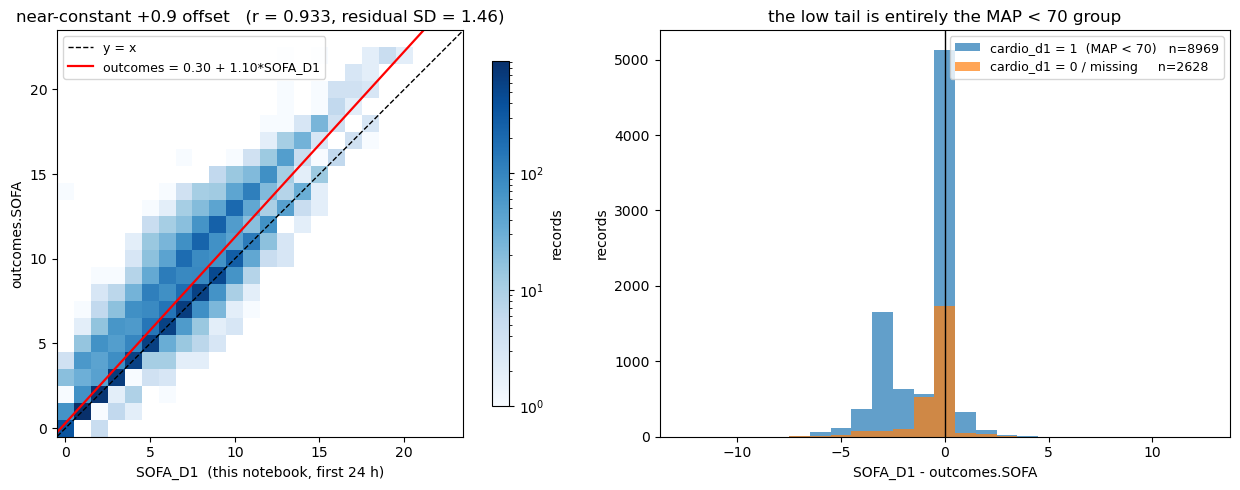

In [15]:
from matplotlib.colors import LogNorm

fig, ax = plt.subplots(1, 2, figsize=(13, 5))

slope, intercept, rr, _, _ = stats.linregress(m.SOFA_D1, m.SOFA)
resid_sd = (m.SOFA - (intercept + slope * m.SOFA_D1)).std()
hi = int(max(m.SOFA_D1.max(), m.SOFA.max())) + 1
edges = np.arange(-0.5, hi + 1.5, 1)
H, _, _ = np.histogram2d(m.SOFA_D1, m.SOFA, bins=[edges, edges])
pcm = ax[0].pcolormesh(edges, edges, H.T, cmap="Blues", norm=LogNorm(vmin=1, vmax=H.max()))
xs = np.array([-0.5, hi + 0.5])
ax[0].plot(xs, xs, "k--", lw=1, label="y = x")
ax[0].plot(xs, intercept + slope * xs, "r-", lw=1.6,
           label=f"outcomes = {intercept:.2f} + {slope:.2f}*SOFA_D1")
ax[0].set(xlabel="SOFA_D1  (this notebook, first 24 h)", ylabel="outcomes.SOFA",
          xlim=(-0.5, hi + 0.5), ylim=(-0.5, hi + 0.5), aspect="equal",
          title=f"near-constant +{m.SOFA.mean() - m.SOFA_D1.mean():.1f} offset   "
                f"(r = {rr:.3f}, residual SD = {resid_sd:.2f})")
ax[0].legend(loc="upper left", fontsize=9)
fig.colorbar(pcm, ax=ax[0], label="records", shrink=0.85)

d = m.SOFA_D1 - m.SOFA
bins = np.arange(-12.5, 13.5, 1)
sel = m.cardio_d1 == 1
ax[1].hist(d[sel],  bins=bins, alpha=.7, label=f"cardio_d1 = 1  (MAP < 70)   n={int(sel.sum())}")
ax[1].hist(d[~sel], bins=bins, alpha=.7, label=f"cardio_d1 = 0 / missing     n={int((~sel).sum())}")
ax[1].axvline(0, color="k", lw=1)
ax[1].set(xlabel="SOFA_D1 - outcomes.SOFA", ylabel="records",
          title="the low tail is entirely the MAP < 70 group")
ax[1].legend(fontsize=9)

plt.tight_layout()
plt.show()


**Three reasons `SOFA_D1` ≠ `outcomes.SOFA` exactly — none of them a scoring error:**

1. **No vasopressor data → cardiovascular capped at 0–1.** This is the *entire* mean bias:
   the reference SOFA's cardiovascular sub-score averages ≈ 1.6 points/patient, ours ≈ 0.8,
   and the 0.8-point shortfall equals `mean(SOFA_D1 − outcomes.SOFA)`. It is one-directional
   (21 % of patients ≥ 3 low, 5 % any amount high) and concentrates exactly where pressors
   live — 92 % of the `d ≤ −3` tail had `MAP < 70` in Day 1, and the bias is worst in the
   cardiac-surgery ICU (−1.3) where almost every patient leaves theatre on an infusion.
   A patient kept at `MAP` 75 *by* norepinephrine scores cardiovascular 3 in the reference
   and 0 here.

2. **Sedation / intubation inflates our neuro + respiratory** in the small `d ≥ +1` tail:
   80 % of it has `GCS ≤ 9` and its mean respiratory score is well above the cohort. We take
   the low GCS and poor P/F at face value; the reference evidently discounted some of it.
   SOFA-1 has no mechanism to separate sedation from brain injury (doc §7).

3. **Everything else is ±1–2 scatter** (residual SD ≈ 1.5 around a slope-≈1 line): the
   challenge never published its exact SOFA recipe — sedated-GCS handling, the renal urine
   sub-score on a first day that is < 24 h long, P/F pairing tolerance and SpO₂/FiO₂
   substitution, lab LOCF windows, `<` vs `≤` at the cut-points, how the "first 24 h" window
   is anchored — plus this notebook's "missing system → 0" rule and the fact that
   `data/icu_records/` is a **de-identified, down-sampled extract**, not the full-resolution
   record the reference was computed from.

`outcomes ≈ 0.30 + 1.10 · SOFA_D1` (r 0.93): a near-constant additive offset from the missing
cardiovascular points, not a distortion — consistent with `outcomes.SOFA` being a first-24 h
SOFA computed with inputs this dataset does not contain.


## 6&nbsp;&nbsp;Plots

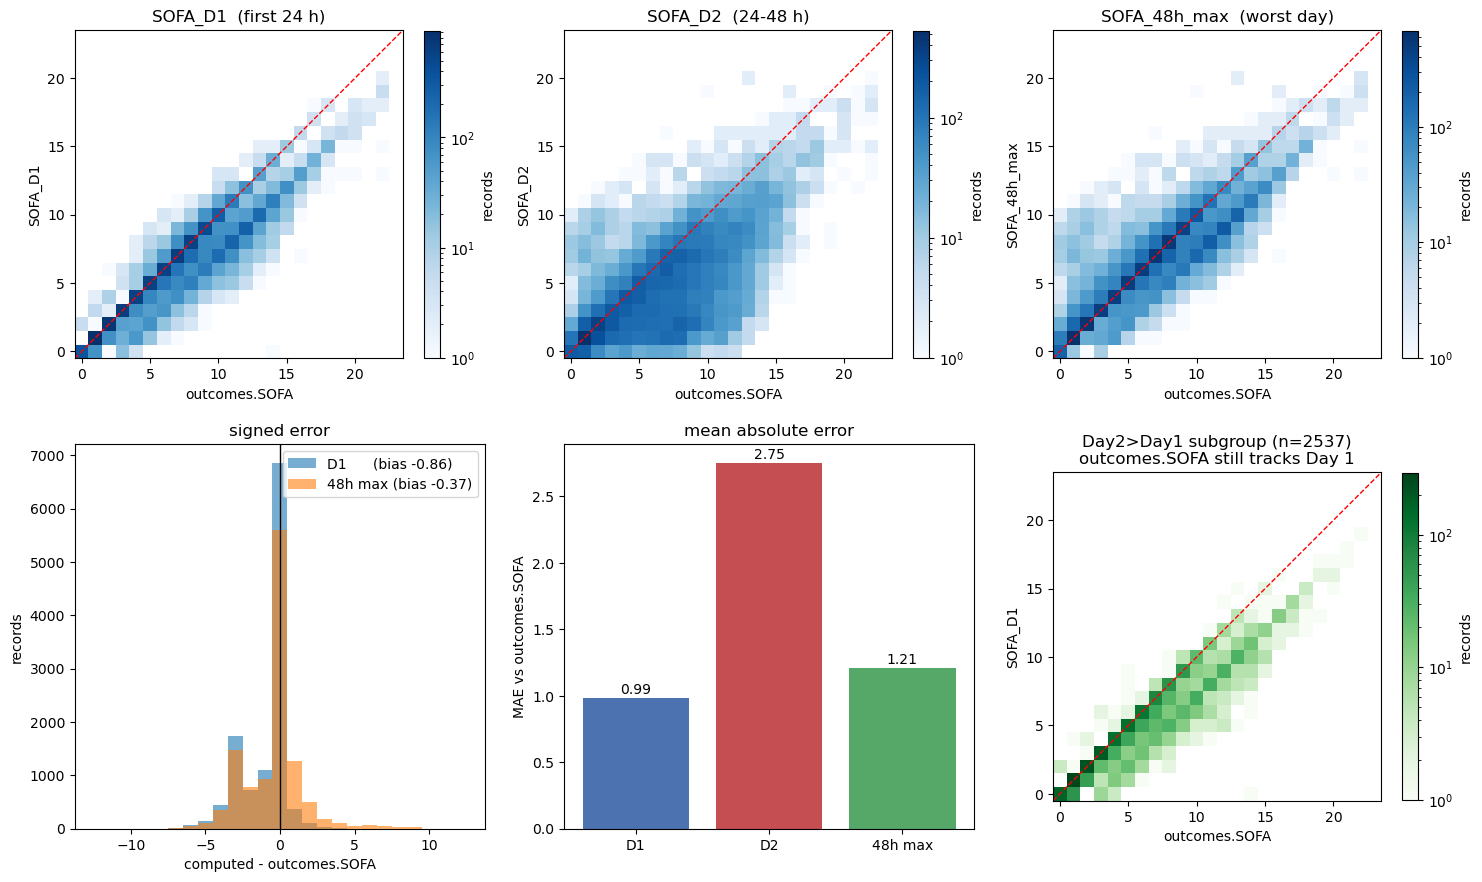

In [16]:
from matplotlib.colors import LogNorm

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

def heat(ax, x, y, ylab, title, cmap="Blues"):
    hi = int(max(x.max(), y.max())) + 1
    edges = np.arange(-0.5, hi + 1.5, 1)
    H, _, _ = np.histogram2d(x, y, bins=[edges, edges])
    pcm = ax.pcolormesh(edges, edges, H.T, cmap=cmap, norm=LogNorm(vmin=1, vmax=H.max()))
    ax.plot([-0.5, hi + 0.5], [-0.5, hi + 0.5], "r--", lw=1)
    ax.set(xlim=(-0.5, hi + 0.5), ylim=(-0.5, hi + 0.5),
           xlabel="outcomes.SOFA", ylabel=ylab, title=title, aspect="equal")
    fig.colorbar(pcm, ax=ax, label="records", shrink=0.85)

heat(axes[0, 0], m.SOFA, m.SOFA_D1,      "SOFA_D1",      "SOFA_D1  (first 24 h)")
heat(axes[0, 1], m.SOFA, m.SOFA_D2,      "SOFA_D2",      "SOFA_D2  (24-48 h)")
heat(axes[0, 2], m.SOFA, m.SOFA_48h_max, "SOFA_48h_max", "SOFA_48h_max  (worst day)")

ax = axes[1, 0]
bins = np.arange(-12.5, 13.5, 1)
ax.hist(m.SOFA_D1      - m.SOFA, bins=bins, alpha=.6, label=f"D1      (bias {(m.SOFA_D1-m.SOFA).mean():+.2f})")
ax.hist(m.SOFA_48h_max - m.SOFA, bins=bins, alpha=.6, label=f"48h max (bias {(m.SOFA_48h_max-m.SOFA).mean():+.2f})")
ax.axvline(0, color="k", lw=1)
ax.set(xlabel="computed - outcomes.SOFA", ylabel="records", title="signed error"); ax.legend()

ax = axes[1, 1]
mae = [(m[c] - m.SOFA).abs().mean() for c in ["SOFA_D1", "SOFA_D2", "SOFA_48h_max"]]
ax.bar(["D1", "D2", "48h max"], mae, color=["#4c72b0", "#c44e52", "#55a868"])
for i, val in enumerate(mae):
    ax.text(i, val + .03, f"{val:.2f}", ha="center")
ax.set(ylabel="MAE vs outcomes.SOFA", title="mean absolute error")

heat(axes[1, 2], g.SOFA, g.SOFA_D1, "SOFA_D1",
     f"Day2>Day1 subgroup (n={len(g)})\noutcomes.SOFA still tracks Day 1", cmap="Greens")

plt.tight_layout()
plt.show()


## 7&nbsp;&nbsp;Verdict

In [17]:
d1  = full_agree(m.SOFA_D1,      m.SOFA)
d48 = full_agree(m.SOFA_48h_max, m.SOFA)
gd1, gmx = full_agree(g.SOFA_D1, g.SOFA), full_agree(g.SOFA_48h_max, g.SOFA)

print(f"""VERDICT  (n = {len(m)} labelled records; {len(g)} with Day 2 > Day 1)

                       exact     +-1      MAE     bias(computed-outcomes)   r
  SOFA_D1 (first 24h)  {d1['exact_pct']:>5}%  {d1['within1_pct']:>5}%  {d1['MAE']:>6}      {d1['bias']:>+6}            {d1['pearson_r']}
  SOFA_48h_max (worst) {d48['exact_pct']:>5}%  {d48['within1_pct']:>5}%  {d48['MAE']:>6}      {d48['bias']:>+6}            {d48['pearson_r']}

  In the Day2>Day1 subgroup (where the two definitions disagree):
  SOFA_D1              {gd1['exact_pct']:>5}%  MAE {gd1['MAE']}   bias {gd1['bias']:+}
  SOFA_48h_max         {gmx['exact_pct']:>5}%  MAE {gmx['MAE']}   bias {gmx['bias']:+}

=> outcomes.SOFA tracks the FIRST-24-HOUR (Day 1) SOFA, not the 48-hour worst.
   When Day 2 is the worse day, outcomes.SOFA stays with Day 1 (~same exact-match rate as
   the whole cohort) while SOFA_48h_max pulls away and overshoots outcomes.SOFA by ~+1.3.

   SOFA_D1 sits ~{abs(d1['bias']):.1f} point BELOW outcomes.SOFA on average. Section 5.2 shows
   this offset is ENTIRELY the cardiovascular component: SOFA's cardiovascular 2-4 needs
   vasopressor drug/dose data, which this dataset does not contain, so our cardiovascular
   score is capped at 0-1. The implied reference cardiovascular average (~1.6) minus ours
   (~0.8) equals the total bias; the other five systems net to ~0. It is an input gap, not a
   definitional mismatch. SOFA_48h_max's smaller apparent bias is a coincidence: the Day-2
   worst-value inflation partly cancels that structural under-scoring.

   This matches the PhysioNet/CinC Challenge 2012 data documentation, in which SAPS-I and
   SOFA in outcomes.csv are first-24-hour severity scores.""")


VERDICT  (n = 11597 labelled records; 2537 with Day 2 > Day 1)

                       exact     +-1      MAE     bias(computed-outcomes)   r
  SOFA_D1 (first 24h)   59.2%   71.9%   0.985      -0.862            0.933
  SOFA_48h_max (worst)  48.3%   67.3%   1.211      -0.375            0.878

  In the Day2>Day1 subgroup (where the two definitions disagree):
  SOFA_D1               60.2%  MAE 0.976   bias -0.929
  SOFA_48h_max          10.5%  MAE 2.007   bias +1.296

=> outcomes.SOFA tracks the FIRST-24-HOUR (Day 1) SOFA, not the 48-hour worst.
   When Day 2 is the worse day, outcomes.SOFA stays with Day 1 (~same exact-match rate as
   the whole cohort) while SOFA_48h_max pulls away and overshoots outcomes.SOFA by ~+1.3.

   SOFA_D1 sits ~0.9 point BELOW outcomes.SOFA on average. Section 5.2 shows
   this offset is ENTIRELY the cardiovascular component: SOFA's cardiovascular 2-4 needs
   vasopressor drug/dose data, which this dataset does not contain, so our cardiovascular
   score is ca

## 8&nbsp;&nbsp;Write `preprocessed/task1_sofa/sofa_scores_extended.csv`

One row per patient: the six SOFA fields (lenient + strict), the twelve per-system
sub-scores, the twelve presence flags, and the admission descriptors.


In [18]:
AGG = ["SOFA_D1", "SOFA_D2", "SOFA_48h_max",
       "SOFA_D1_strict", "SOFA_D2_strict", "SOFA_48h_max_strict"]
sub = [f"{s}_{d}" for d in ("d1", "d2") for s in SYSTEMS]
pres = [f"{s}_{d}_present" for d in ("d1", "d2") for s in SYSTEMS]
cols = ["RecordID"] + AGG + sub + pres + ["Age", "Gender", "ICUType", "Weight"]

out_path = PROJ / "preprocessed" / "task1_sofa" / "sofa_scores_extended.csv"
out_path.parent.mkdir(parents=True, exist_ok=True)
scores[cols].to_csv(out_path, index=False)
print("wrote", out_path, scores[cols].shape)
scores[["RecordID"] + AGG].describe().round(2)


wrote preprocessed/task1_sofa/sofa_scores_extended.csv (12000, 35)


,RecordID,SOFA_D1,SOFA_D2,SOFA_48h_max,SOFA_D1_strict,SOFA_D2_strict,SOFA_48h_max_strict
count,12000.00,12000.00,12000.00,12000.00,2576.00,1419.00,934.00
mean,106000.50,5.75,4.62,6.24,8.78,9.15,10.75
std,3464.25,3.46,3.41,3.46,2.96,3.37,3.17
min,100001.00,0.00,0.00,0.00,1.00,0.00,2.00
25%,103000.75,3.00,2.00,3.00,7.00,7.00,9.00
50%,106000.50,6.00,4.00,6.00,9.00,9.00,10.50
75%,109000.25,8.00,7.00,9.00,11.00,11.00,13.00
max,112000.00,20.00,20.00,20.00,20.00,20.00,20.00


## 9&nbsp;&nbsp;Assumptions & known deviations

* **`SOFA_D1` runs ≈ 1 point below `outcomes.SOFA`** and matches it exactly ~59 % of the
  time. §5.2 attributes this in full: the cardiovascular component is capped at 0–1 because
  the dataset has no vasopressor drug/dose data (the reference SOFA, built on MIMIC-II, does).
  The gap is one-directional and concentrates in `MAP < 70` / cardiac-surgery patients; the
  remaining ±1–2 scatter is the challenge's unpublished exact SOFA recipe plus the
  missing-system→0 rule. This is expected behaviour, not a scoring error, and does not affect
  the first-24 h-vs-48 h-worst conclusion.
* **`100008`** is the only row of doc Table 5 not reproduced (doc Day 2 = 4; here 1). That
  record has a single `PaO2 = 116` at `23:13` with **no `FiO2` anywhere** and **no
  `MechVent`** – no documented rule yields a Day-2 score of 4, so this is treated as an
  artefact of the doc's 26-row trial run. The Day-1 agreement statistics (doc Table 6)
  reproduce to the digit.
* "Urine records represent a full 24 h" is operationalised as **window span ≥ 20 h** (doc
  gives 20 h as the reference cut in Table 4 but no exact threshold in §5); no rate-scaling.
* **Respiratory support** = `MechVent` within ±2 h of the lowest-ratio `PaO2` (doc §5
  "附近的 MechVent"). Doc §7 alternatively phrases this as "anywhere in the window"; the
  ±2 h reading is what reproduces doc Table 5 (`100023`).
* FiO₂/MechVent pairing ties (equal `|Δt|` on both sides) resolve to the earlier reading.
* `SOFA_*_strict` counts a **LOCF-carried** bilirubin as missing; the lenient total uses it.
* `SOFA_48h_max_strict` is defined only when **both** windows are complete, which is why its
  coverage (~8%) is far below the Day-1 strict rate (~22%, doc §7's "~2,640").
